In [61]:
from __future__ import annotations

import csv
import itertools
import math
import random
import statistics
from collections import Counter, defaultdict
from pathlib import Path
from typing import Any

#constants and configurations for the functions
csv_file = Path("Topic3_healthcare_analytics_dataset.csv")

age_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
]

stay_order = [
    "0-10",
    "11-20",
    "21-30",
    "31-40",
    "41-50",
    "51-60",
    "61-70",
    "71-80",
    "81-90",
    "91-100",
    "More than 100 Days",
]

age_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
}

stay_midpoints = {
    "0-10": 5.0,
    "11-20": 15.5,
    "21-30": 25.5,
    "31-40": 35.5,
    "41-50": 45.5,
    "51-60": 55.5,
    "61-70": 65.5,
    "71-80": 75.5,
    "81-90": 85.5,
    "91-100": 95.5,
    "More than 100 Days": 110.0,
}

expected_categories = {
    "Age": age_order,
    "Stay": stay_order,
    "Type of Admission": ["Emergency", "Trauma", "Urgent"],
    "Severity of Illness": ["Minor", "Moderate", "Extreme"],
}

identifier_columns = {"case_id", "patientid"}

interaction_features = [
    "Age",
    "Available Extra Rooms in Hospital",
    "Visitors with Patient",
    "Admission_Deposit",
    "Bed Grade",
]

heatmap_pairs = [
    ("Age", "Severity of Illness"),
    ("Age", "Type of Admission"),
    ("Department", "Severity of Illness"),
    ("Department", "Type of Admission"),
]

target_scatter_features = [
    "Age",
    "Available Extra Rooms in Hospital",
    "Visitors with Patient",
    "Admission_Deposit",
]

categorical_association_features = [
    "Hospital_code",
    "Hospital_type_code",
    "City_Code_Hospital",
    "Hospital_region_code",
    "Department",
    "Ward_Type",
    "Ward_Facility_Code",
    "City_Code_Patient",
    "Type of Admission",
    "Severity of Illness",
    "Age",
    "Bed Grade",
]

categorical_mean_stay_features = [
    "Department",
    "Type of Admission",
    "Severity of Illness",
    "Ward_Type",
]

try:
    import pandas as pd
except ImportError:
    pd = None

In [62]:
def print_section(title: str) -> None:
    """Prints a heading for visual separation"""
    print("\n" + "-" * 40)
    print(title)
    print("-" * 40)

print_section("Print section example")


----------------------------------------
Print section example
----------------------------------------


In [63]:
def clean_text(value: Any) -> str:
    """Converts one CSV value into cleaned text. Empty values become an empty string and surrounding spaces are removed, which prevents hidden whitespace from creating false categories."""
    return "" if value is None else str(value).strip()

print(clean_text("  Example value  "))

Example value


In [64]:
def to_number(value: Any) -> float | None:
    """Convert a value into a number. If the value is empty or non-numeric, it returns None. This is used before numeric summaries, correlations, and outlier checks."""
    text = clean_text(value)
    if text == "":
        return None
    try:
        number = float(text)
    except ValueError:
        return None
    if math.isnan(number):
        return None
    return number

print(to_number("42"))

42.0


In [65]:
def format_number(value: float | None, digits: int = 2) -> str:
    """Formats values for output. Whole numbers are shown without unnecessary decimals and decimal values are rounded."""
    if value is None:
        return "n/a"
    if float(value).is_integer():
        return str(int(value))
    return f"{value:.{digits}f}"

print(format_number(42.0))

42


In [66]:
def percentile(sorted_values: list[float], percent: float) -> float | None:
    """Calculates a percentile from a sorted list. It is used for Q1, median, and Q3 in the numeric summary and outlier detection."""
    if not sorted_values:
        return None
    if len(sorted_values) == 1:
        return sorted_values[0]

    position = (len(sorted_values) - 1) * percent
    lower_index = math.floor(position)
    upper_index = math.ceil(position)
    if lower_index == upper_index:
        return sorted_values[int(position)]

    lower_value = sorted_values[lower_index]
    upper_value = sorted_values[upper_index]
    return lower_value + (upper_value - lower_value) * (position - lower_index)

print(percentile([1.0, 2.0, 3.0, 4.0], 0.5))

2.5


In [67]:
def load_rows(csv_path: Path = csv_file) -> tuple[list[dict[str, str]], list[str]]:
    """Returns the rows plus column names."""
    with csv_path.open(newline="", encoding="utf-8") as file:
        reader = csv.DictReader(file)
        rows = [{key: clean_text(value) for key, value in row.items()} for row in reader]
        columns = list(reader.fieldnames or [])
    return rows, columns

rows, columns = load_rows(csv_file)

print(len(rows), len(columns))

313793 18


In [68]:
def infer_numeric_columns(rows: list[dict[str, str]], columns: list[str]) -> list[str]:
    """Checks which columns contain numeric values."""
    numeric_columns = []
    for column in columns:
        values = [row[column] for row in rows if row[column] != ""]
        if values and all(to_number(value) is not None for value in values):
            numeric_columns.append(column)
    return numeric_columns


numeric_columns = infer_numeric_columns(rows, columns)
print(numeric_columns[:10])

['case_id', 'Hospital_code', 'City_Code_Hospital', 'Available Extra Rooms in Hospital', 'Bed Grade', 'patientid', 'City_Code_Patient', 'Visitors with Patient', 'Admission_Deposit']


In [69]:
def sorted_unique_values(values: list[str]) -> list[str]:
    """Sorts unique values in a readable order. Helps keep graph labels and category labels clean."""
    return sorted(set(values), key=lambda item: (to_number(item) is None, to_number(item) or 0, item))

print(sorted_unique_values(["b", "a", "b"]))

['a', 'b']


In [70]:
def numeric_values(rows: list[dict[str, str]], column: str) -> list[float]:
    """Collects numeric values from one selected column and ignores missing or non-numeric values. This is used for summaries"""
    return [number for row in rows if (number := to_number(row[column])) is not None]

print(numeric_values(rows, "Age")[:5])

[]


In [71]:
def print_basic_overview(rows: list[dict[str, str]], columns: list[str], numeric_columns: list[str]) -> None:
    """Prints dbasic overview"""
    print_section("Basic overview")
    print(f"Rows: {len(rows):,}")
    print(f"Columns: {len(columns):,}")
    print("\nColumn types inferred from CSV text:")
    for column in columns:
        inferred_type = "numeric" if column in numeric_columns else "text/category"
        print(f"{column}: {inferred_type}")

print_basic_overview(rows, columns, numeric_columns)


----------------------------------------
Basic overview
----------------------------------------
Rows: 313,793
Columns: 18

Column types inferred from CSV text:
case_id: numeric
Hospital_code: numeric
Hospital_type_code: text/category
City_Code_Hospital: numeric
Hospital_region_code: text/category
Available Extra Rooms in Hospital: numeric
Department: text/category
Ward_Type: text/category
Ward_Facility_Code: text/category
Bed Grade: numeric
patientid: numeric
City_Code_Patient: numeric
Type of Admission: text/category
Severity of Illness: text/category
Visitors with Patient: numeric
Age: text/category
Admission_Deposit: numeric
Stay: text/category


In [72]:
def print_missing_values(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Checks whether missing values are still present"""
    print_section("Missing values")
    missing_counts = {column: sum(1 for row in rows if row[column] == "") for column in columns}
    rows_with_missing = sum(1 for row in rows if any(row[column] == "" for column in columns))

    print(f"Rows with at least one missing value: {rows_with_missing:,} ({rows_with_missing / len(rows) * 100:.2f}%)")
    missing_columns = {column: count for column, count in missing_counts.items() if count > 0}
    if not missing_columns:
        print("No missing values found.")
        return

    for column, count in missing_columns.items():
        print(f"{column}: {count:,} ({count / len(rows) * 100:.2f}%)")

print_missing_values(rows, columns)


----------------------------------------
Missing values
----------------------------------------
Rows with at least one missing value: 0 (0.00%)
No missing values found.


In [73]:
def print_duplicates(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Checks for fully duplicated rows, repeated identifiers, and whether case_id is continuous."""
    print_section("Duplicates")
    row_keys = [tuple(row[column] for column in columns) for row in rows]
    full_duplicate_rows = sum(count - 1 for count in Counter(row_keys).values() if count > 1)
    print(f"Fully duplicated rows: {full_duplicate_rows:,}")

    for column in ["case_id", "patientid"]:
        if column not in columns:
            continue
        values = [row[column] for row in rows]
        unique_count = len(set(values))
        duplicate_count = len(values) - unique_count
        print(f"{column}: {unique_count:,} unique values, {duplicate_count:,} repeated rows")

    if "case_id" in columns:
        case_ids = [to_number(row["case_id"]) for row in rows]
        expected = list(range(1, len(rows) + 1))
        continuous = case_ids == expected
        print(f"case_id is continuous from 1 to n: {continuous}")

print_duplicates(rows, columns)


----------------------------------------
Duplicates
----------------------------------------
Fully duplicated rows: 0
case_id: 313,793 unique values, 0 repeated rows
patientid: 90,344 unique values, 223,449 repeated rows
case_id is continuous from 1 to n: True


In [74]:
def print_numeric_summary(rows: list[dict[str, str]], numeric_columns: list[str]) -> None:
    """Prints descriptive statistics for numeric columns: count, missing values, min, Q1, median, mean, Q3, max, and standard deviation."""
    print_section("Numeric summary")
    if not numeric_columns:
        print("No numeric columns found.")
        return

    header = f"{'column':38} {'count':>9} {'missing':>9} {'min':>10} {'q1':>10} {'median':>10} {'mean':>10} {'q3':>10} {'max':>10} {'std':>10}"
    print(header)
    print("-" * len(header))
    for column in numeric_columns:
        values = sorted(numeric_values(rows, column))
        missing = len(rows) - len(values)
        std_value = statistics.stdev(values) if len(values) > 1 else 0.0
        line = (
            f"{column:38} {len(values):9,} {missing:9,} "
            f"{format_number(min(values)):>10} {format_number(percentile(values, 0.25)):>10} "
            f"{format_number(percentile(values, 0.50)):>10} {format_number(statistics.mean(values)):>10} "
            f"{format_number(percentile(values, 0.75)):>10} {format_number(max(values)):>10} {format_number(std_value):>10}"
        )
        print(line)

print_numeric_summary(rows, numeric_columns)


----------------------------------------
Numeric summary
----------------------------------------
column                                     count   missing        min         q1     median       mean         q3        max        std
---------------------------------------------------------------------------------------------------------------------------------------
case_id                                  313,793         0          1      78449     156897     156897     235345     313793   90584.38
Hospital_code                            313,793         0          1         11         19      18.33         26         32       8.63
City_Code_Hospital                       313,793         0          1          2          5       4.78          7         13       3.10
Available Extra Rooms in Hospital        313,793         0          0          2          3       3.20          4         24       1.17
Bed Grade                                313,793         0          1          2     

In [75]:
def get_outlier_rows(rows: list[dict[str, str]], numeric_columns: list[str]) -> list[dict[str, Any]]:
    """Calculates possible outliers using the IQR rule. It returns lower/upper bounds, outlier counts, percentages, and min/max values for numeric columns."""
    outlier_rows = []
    for column in numeric_columns:
        if column in identifier_columns:
            continue

        values = sorted(numeric_values(rows, column))
        if not values:
            continue
        q1 = percentile(values, 0.25)
        q3 = percentile(values, 0.75)
        if q1 is None or q3 is None:
            continue

        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = [value for value in values if value < lower_bound or value > upper_bound]
        outlier_rows.append(
            {
                "column": column,
                "q1": q1,
                "q3": q3,
                "iqr": iqr,
                "lower_bound": lower_bound,
                "upper_bound": upper_bound,
                "outliers": len(outliers),
                "outlier_percent": len(outliers) / len(values) * 100,
                "min": min(values),
                "max": max(values),
            }
        )
    return sorted(outlier_rows, key=lambda row: row["outliers"], reverse=True)

print(get_outlier_rows(rows, numeric_columns)[:3])

[{'column': 'City_Code_Patient', 'q1': 4.0, 'q3': 8.0, 'iqr': 4.0, 'lower_bound': -2.0, 'upper_bound': 14.0, 'outliers': 24770, 'outlier_percent': 7.893738866067758, 'min': 1.0, 'max': 38.0}, {'column': 'Admission_Deposit', 'q1': 4188.0, 'q3': 5410.0, 'iqr': 1222.0, 'lower_bound': 2355.0, 'upper_bound': 7243.0, 'outliers': 12130, 'outlier_percent': 3.8656056699798915, 'min': 1800.0, 'max': 11008.0}, {'column': 'Visitors with Patient', 'q1': 2.0, 'q3': 4.0, 'iqr': 2.0, 'lower_bound': -1.0, 'upper_bound': 7.0, 'outliers': 9612, 'outlier_percent': 3.063165844999729, 'min': 0.0, 'max': 32.0}]


In [76]:
def print_outliers(rows: list[dict[str, str]], numeric_columns: list[str]) -> None:
    """Prints the IQR outlier results. For this dataset, real numeric variables such as visitors and admission deposit are most important."""
    print_section("Possible numeric outliers using IQR rule")
    outlier_rows = get_outlier_rows(rows, numeric_columns)
    if not outlier_rows:
        print("No numeric columns available for outlier detection.")
        return

    header = f"{'column':38} {'q1':>10} {'q3':>10} {'lower':>10} {'upper':>10} {'outliers':>10} {'percent':>9} {'min':>10} {'max':>10}"
    print(header)
    print("-" * len(header))
    for row in outlier_rows:
        print(
            f"{row['column']:38} {format_number(row['q1']):>10} {format_number(row['q3']):>10} "
            f"{format_number(row['lower_bound']):>10} {format_number(row['upper_bound']):>10} "
            f"{row['outliers']:10,} {row['outlier_percent']:8.2f}% {format_number(row['min']):>10} {format_number(row['max']):>10}"
        )

    print(
        "\nInterpretation: codes such as Hospital_code and City_Code_Hospital are labels, "
        "so mathematical outliers there are not automatically data errors. For real "
        "outliers, we should focus focus on Available Extra Rooms in Hospital, Visitors with "
        "Patient, and Admission_Deposit."
    )

print_outliers(rows, numeric_columns)


----------------------------------------
Possible numeric outliers using IQR rule
----------------------------------------
column                                         q1         q3      lower      upper   outliers   percent        min        max
-----------------------------------------------------------------------------------------------------------------------------
City_Code_Patient                               4          8         -2         14     24,770     7.89%          1         38
Admission_Deposit                            4188       5410       2355       7243     12,130     3.87%       1800      11008
Visitors with Patient                           2          4         -1          7      9,612     3.06%          0         32
Available Extra Rooms in Hospital               2          4         -1          7      1,336     0.43%          0         24
Hospital_code                                  11         26     -11.50      48.50          0     0.00%          1      

In [77]:
def print_unexpected_categories(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Checks important columns against expected labels. This catches unexpected values and whitespace problems."""
    print_section("Unexpected category check")
    found_issue = False
    for column, expected_values in expected_categories.items():
        if column not in columns:
            continue

        actual_values = {row[column] for row in rows if row[column] != ""}
        unexpected = sorted(actual_values - set(expected_values))
        missing_expected = sorted(set(expected_values) - actual_values)
        if unexpected or missing_expected:
            found_issue = True
            print(f"\n{column}")
            print(f"unexpected values: {unexpected if unexpected else 'none'}")
            print(f"expected values not present: {missing_expected if missing_expected else 'none'}")

    if not found_issue:
        print("No unexpected values found in the checked ordered/category columns.")

print_unexpected_categories(rows, columns)


----------------------------------------
Unexpected category check
----------------------------------------
No unexpected values found in the checked ordered/category columns.


In [78]:
def rank_from_order(value: str, order: list[str]) -> float | None:
    """Converts an ordered category into a numeric rank. This is used for interval variables such as Age and Stay so they can be used in correlations."""
    try:
        return float(order.index(value) + 1)
    except ValueError:
        return None

print(rank_from_order("21-30", age_order))

3.0


In [79]:
def pearson_correlation(first_values: list[float], second_values: list[float]) -> float | None:
    """Calculates correlation between two numeric lists."""
    if len(first_values) != len(second_values) or len(first_values) < 2:
        return None
    first_mean = statistics.mean(first_values)
    second_mean = statistics.mean(second_values)
    numerator = sum((x - first_mean) * (y - second_mean) for x, y in zip(first_values, second_values))
    first_denominator = math.sqrt(sum((x - first_mean) ** 2 for x in first_values))
    second_denominator = math.sqrt(sum((y - second_mean) ** 2 for y in second_values))
    denominator = first_denominator * second_denominator
    if denominator == 0:
        return None
    return numerator / denominator

print(pearson_correlation([1.0, 2.0, 3.0], [1.0, 2.0, 4.0]))

0.9819805060619655


In [80]:
def print_correlations(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Prints first-order correlations between Stay rank and selected variables. This helps identify possible predictors of length of stay."""
    print_section("First useful correlations with length of stay")
    candidate_columns = [
        "Age",
        "Available Extra Rooms in Hospital",
        "Visitors with Patient",
        "Admission_Deposit",
        "Bed Grade",
    ]

    for column in candidate_columns:
        if column not in columns:
            continue
        stay_ranks = []
        candidate_values = []
        for row in rows:
            stay_rank = rank_from_order(row["Stay"], stay_order)
            if column == "Age":
                candidate_value = rank_from_order(row[column], age_order)
            else:
                candidate_value = to_number(row[column])
            if stay_rank is not None and candidate_value is not None:
                stay_ranks.append(stay_rank)
                candidate_values.append(candidate_value)

        correlation = pearson_correlation(stay_ranks, candidate_values)
        print(f"{column}: {format_number(correlation, digits=4)}")

print_correlations(rows, columns)


----------------------------------------
First useful correlations with length of stay
----------------------------------------
Age: 0.0940
Available Extra Rooms in Hospital: -0.1216
Visitors with Patient: 0.5375
Admission_Deposit: -0.0521
Bed Grade: 0.0251


In [81]:
def feature_numeric_value(row: dict[str, str], feature: str) -> float | None:
    """Returns a numeric representation for a selected feature in a row."""
    if feature == "Age":
        return rank_from_order(row[feature], age_order)
    if feature == "Stay":
        return rank_from_order(row[feature], stay_order)
    return to_number(row.get(feature, ""))

print(feature_numeric_value(rows[0], "Age") if rows else None)

6.0


In [82]:
def get_second_order_interactions(rows: list[dict[str, str]], columns: list[str]) -> list[dict[str, Any]]:
    """Builds pairwise interaction terms such as Age * Visitors with Patient and correlates them with Stay. This checks whether feature combinations may be useful for prediction."""
    available_features = [feature for feature in interaction_features if feature in columns]
    interactions = []

    for first_feature, second_feature in itertools.combinations(available_features, 2):
        stay_ranks = []
        interaction_values = []

        for row in rows:
            stay_rank = rank_from_order(row["Stay"], stay_order)
            first_value = feature_numeric_value(row, first_feature)
            second_value = feature_numeric_value(row, second_feature)

            if stay_rank is None or first_value is None or second_value is None:
                continue

            stay_ranks.append(stay_rank)
            interaction_values.append(first_value * second_value)

        correlation = pearson_correlation(stay_ranks, interaction_values)
        interactions.append(
            {
                "first_feature": first_feature,
                "second_feature": second_feature,
                "interaction": f"{first_feature} x {second_feature}",
                "correlation": correlation,
                "absolute_correlation": abs(correlation) if correlation is not None else 0,
                "rows_used": len(stay_ranks),
            }
        )

    return sorted(interactions, key=lambda row: row["absolute_correlation"], reverse=True)

print(get_second_order_interactions(rows, columns)[:3])

[{'first_feature': 'Visitors with Patient', 'second_feature': 'Admission_Deposit', 'interaction': 'Visitors with Patient x Admission_Deposit', 'correlation': 0.47461870060323275, 'absolute_correlation': 0.47461870060323275, 'rows_used': 313793}, {'first_feature': 'Age', 'second_feature': 'Visitors with Patient', 'interaction': 'Age x Visitors with Patient', 'correlation': 0.46880640569282445, 'absolute_correlation': 0.46880640569282445, 'rows_used': 313793}, {'first_feature': 'Visitors with Patient', 'second_feature': 'Bed Grade', 'interaction': 'Visitors with Patient x Bed Grade', 'correlation': 0.4513195215298822, 'absolute_correlation': 0.4513195215298822, 'rows_used': 313793}]


In [83]:
def print_second_order_interactions(rows: list[dict[str, str]], columns: list[str], limit: int = 15) -> None:
    """Prints the strongest interaction correlations. This gives an advanced correlation check beyond single-variable checks."""
    print_section("Second-order interaction correlations with length of stay")
    interactions = get_second_order_interactions(rows, columns)
    if not interactions:
        print("No interaction terms could be calculated.")
        return

    print(
        "These are correlations between Stay_rank and pairwise products such as "
        "Age_rank * Visitors with Patient. Useful for predicting length of stay."
    )
    print(f"\n{'interaction':75} {'corr':>10} {'rows':>9}")
    print("-" * 98)
    for row in interactions[:limit]:
        print(f"{row['interaction']:75} {format_number(row['correlation'], digits=4):>10} {row['rows_used']:9,}")

print_second_order_interactions(rows, columns)


----------------------------------------
Second-order interaction correlations with length of stay
----------------------------------------
These are correlations between Stay_rank and pairwise products such as Age_rank * Visitors with Patient. Useful for predicting length of stay.

interaction                                                                       corr      rows
--------------------------------------------------------------------------------------------------
Visitors with Patient x Admission_Deposit                                       0.4746   313,793
Age x Visitors with Patient                                                     0.4688   313,793
Visitors with Patient x Bed Grade                                               0.4513   313,793
Available Extra Rooms in Hospital x Visitors with Patient                       0.3014   313,793
Available Extra Rooms in Hospital x Admission_Deposit                          -0.1324   313,793
Age x Bed Grade                   

In [84]:
def get_grouped_stay_values(rows: list[dict[str, str]], column: str) -> dict[str, list[float]]:
    """Groups Stay midpoint values by a selected feature. This is used for categorical comparisons."""
    groups = defaultdict(list)
    for row in rows:
        stay_midpoint = stay_midpoints.get(row["Stay"])
        if stay_midpoint is not None and row.get(column, "") != "":
            groups[row[column]].append(stay_midpoint)
    return dict(groups)

# print(list(get_grouped_stay_values(rows, "Department").items())[:2])

In [85]:
def eta_squared_for_groups(groups: dict[str, list[float]]) -> float | None:
    """Calculates eta squared (ANOVA test) for grouped Stay values. Eta squared measures how strongly a categorical feature separates the target variable."""
    all_values = [value for values in groups.values() for value in values]
    if len(all_values) < 2:
        return None

    overall_mean = statistics.mean(all_values)
    total_sum_squares = sum((value - overall_mean) ** 2 for value in all_values)
    if total_sum_squares == 0:
        return None

    between_sum_squares = sum(
        len(values) * (statistics.mean(values) - overall_mean) ** 2
        for values in groups.values()
        if values
    )
    return between_sum_squares / total_sum_squares

print(eta_squared_for_groups({"A": [1.0, 2.0], "B": [3.0, 4.0]}))

0.8


In [86]:
def get_categorical_associations(rows: list[dict[str, str]], columns: list[str]) -> list[dict[str, Any]]:
    """Calculates eta squared for selected categorical/code columns and ranks them by association with Stay. This helps identify possible categorical predictors."""
    associations = []
    for column in categorical_association_features:
        if column not in columns or column == "Stay":
            continue

        groups = get_grouped_stay_values(rows, column)
        eta_squared = eta_squared_for_groups(groups)
        associations.append(
            {
                "feature": column,
                "eta_squared": eta_squared,
                "groups": len(groups),
                "rows_used": sum(len(values) for values in groups.values()),
            }
        )

    return sorted(
        associations,
        key=lambda row: row["eta_squared"] if row["eta_squared"] is not None else -1,
        reverse=True,
    )

print(get_categorical_associations(rows, columns)[:3])

[{'feature': 'Ward_Type', 'eta_squared': 0.03695997191346377, 'groups': 6, 'rows_used': 313793}, {'feature': 'Hospital_code', 'eta_squared': 0.02349543585260726, 'groups': 32, 'rows_used': 313793}, {'feature': 'Severity of Illness', 'eta_squared': 0.016010163319286376, 'groups': 3, 'rows_used': 313793}]


In [87]:
def print_categorical_associations(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Prints the categorical association ranking. This is useful because many columns are codes or categories, where normal numeric correlation would be misleading."""
    print_section("Categorical association strength with length of stay")
    associations = get_categorical_associations(rows, columns)
    if not associations:
        print("No categorical associations could be calculated.")
        return

    print(
        "Eta squared shows how much of the variation in Stay_midpoint is separated by "
        "each category/code column. Higher values are better candidates for later ML."
    )
    print(f"\n{'feature':32} {'eta_squared':>12} {'groups':>8} {'rows':>9}")
    print("-" * 68)
    for row in associations:
        print(
            f"{row['feature']:32} {format_number(row['eta_squared'], digits=4):>12} "
            f"{row['groups']:8,} {row['rows_used']:9,}"
        )

print_categorical_associations(rows, columns)


----------------------------------------
Categorical association strength with length of stay
----------------------------------------
Eta squared shows how much of the variation in Stay_midpoint is separated by each category/code column. Higher values are better candidates for later ML.

feature                           eta_squared   groups      rows
--------------------------------------------------------------------
Ward_Type                              0.0370        6   313,793
Hospital_code                          0.0235       32   313,793
Severity of Illness                    0.0160        3   313,793
Age                                    0.0094       10   313,793
Type of Admission                      0.0085        3   313,793
City_Code_Hospital                     0.0073       11   313,793
Ward_Facility_Code                     0.0069        6   313,793
City_Code_Patient                      0.0067       37   313,793
Hospital_type_code                     0.0067        7 

In [88]:
def print_grouped_stay_means(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Prints mean Stay midpoint by selected variables. This gives interpretable comparisons like mean stay by department or admission type."""
    print_section("Average stay midpoint by selected variables")
    group_columns = [
        "Age",
        "Department",
        "Type of Admission",
        "Severity of Illness",
        "Ward_Type",
        "Bed Grade",
    ]

    for column in group_columns:
        if column not in columns:
            continue
        groups = defaultdict(list)
        for row in rows:
            stay_midpoint = stay_midpoints.get(row["Stay"])
            if stay_midpoint is not None:
                groups[row[column]].append(stay_midpoint)

        print(f"\n{column}")
        ordered_groups = sorted(groups.items(), key=lambda item: statistics.mean(item[1]))
        for group, values in ordered_groups:
            print(f"{group}: count={len(values):,}, mean_stay={statistics.mean(values):.2f}")

print_grouped_stay_means(rows, columns)


----------------------------------------
Average stay midpoint by selected variables
----------------------------------------

Age
11-20: count=16,537, mean_stay=28.57
0-10: count=6,190, mean_stay=29.48
21-30: count=40,272, mean_stay=29.99
31-40: count=62,760, mean_stay=31.27
41-50: count=62,633, mean_stay=32.71
51-60: count=47,766, mean_stay=33.62
61-70: count=33,238, mean_stay=34.10
71-80: count=35,354, mean_stay=35.00
91-100: count=1,269, mean_stay=38.63
81-90: count=7,774, mean_stay=39.03

Department
anesthesia: count=29,187, mean_stay=30.57
TB & Chest disease: count=9,460, mean_stay=31.36
gynecology: count=245,850, mean_stay=32.63
radiotherapy: count=28,153, mean_stay=33.73
surgery: count=1,143, mean_stay=38.11

Type of Admission
Urgent: count=47,977, mean_stay=30.40
Emergency: count=115,564, mean_stay=30.66
Trauma: count=150,252, mean_stay=34.62

Severity of Illness
Minor: count=84,319, mean_stay=28.63
Moderate: count=173,425, mean_stay=32.98
Extreme: count=56,049, mean_stay=36.

In [89]:
def order_values_for_plot(column: str, values: list[str]) -> list[str]:
    """Orders category labels for plots. For example, age groups are ordered by interval rather than alphabetically."""
    if column == "Age":
        return [value for value in age_order if value in values]
    if column == "Stay":
        return [value for value in stay_order if value in values]
    if column == "Severity of Illness":
        severity_order = ["Minor", "Moderate", "Extreme"]
        return [value for value in severity_order if value in values]
    return sorted_unique_values(values)

print(order_values_for_plot("Age", ["21-30", "0-10"]))

['0-10', '21-30']


In [90]:
def build_mean_stay_matrix(
    rows: list[dict[str, str]],
    first_column: str,
    second_column: str,
) -> tuple[list[str], list[str], list[list[float]]]:
    """Builds a matrix of mean Stay values for two categorical variables. This matrix is used to draw heatmaps of interaction patterns."""
    first_values = order_values_for_plot(first_column, sorted({row[first_column] for row in rows}))
    second_values = order_values_for_plot(second_column, sorted({row[second_column] for row in rows}))
    grouped_values = defaultdict(list)

    for row in rows:
        stay_midpoint = stay_midpoints.get(row["Stay"])
        if stay_midpoint is None:
            continue
        grouped_values[(row[first_column], row[second_column])].append(stay_midpoint)

    matrix = []
    for first_value in first_values:
        matrix_row = []
        for second_value in second_values:
            values = grouped_values.get((first_value, second_value), [])
            matrix_row.append(statistics.mean(values) if values else math.nan)
        matrix.append(matrix_row)

    return first_values, second_values, matrix

first_values, second_values, matrix = build_mean_stay_matrix(rows, "Age", "Type of Admission")

print(len(first_values), len(second_values), len(matrix))

10 3 10


In [91]:
def require_matplotlib():
    """Checks whether matplotlib is installed before graph functions are called."""
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("Graphs need matplotlib. It is not installed in this Python environment.")
        return None
    return plt

print(require_matplotlib())

<module 'matplotlib.pyplot' from 'c:\\Python314\\Lib\\site-packages\\matplotlib\\pyplot.py'>


In [92]:
def get_target_scatter_points(
    rows: list[dict[str, str]],
    feature: str,
    jitter: float = 0.08,
) -> tuple[list[float], list[float]]:
    """Creates x and y values for scatterplots against Stay rank. A small jitter is added to make overlapping points easier to see."""
    random.seed(42)
    x_values = []
    y_values = []

    for row in rows:
        feature_value = feature_numeric_value(row, feature)
        stay_rank = rank_from_order(row["Stay"], stay_order)
        if feature_value is None or stay_rank is None:
            continue
        x_values.append(feature_value + random.uniform(-jitter, jitter))
        y_values.append(stay_rank + random.uniform(-jitter, jitter))

    return x_values, y_values

#print(get_target_scatter_points(rows, target_scatter_features[0])[:2])

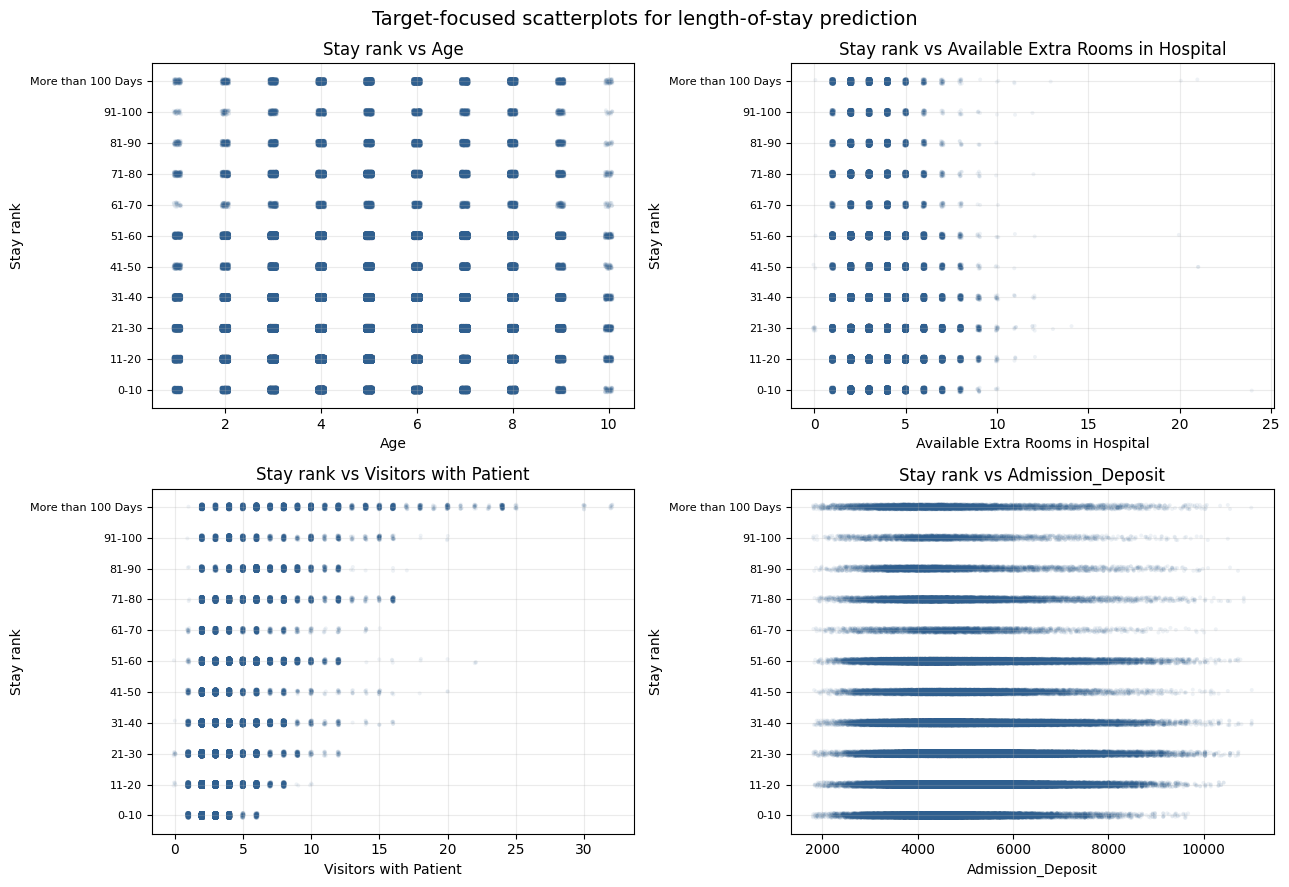

In [59]:
def show_target_scatterplots(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Shows scatterplots of Stay rank against selected predictors. This visualizes possible relationships between length of stay and numeric/ordered variables."""
    plt = require_matplotlib()
    if plt is None:
        return

    available_features = [feature for feature in target_scatter_features if feature in columns]
    if not available_features:
        print("No target scatterplot features are available in the CSV columns.")
        return

    figure, axes = plt.subplots(2, 2, figsize=(13, 9))
    flat_axes = list(axes.flat)

    for axis, feature in zip(flat_axes, available_features):
        x_values, y_values = get_target_scatter_points(rows, feature)
        axis.scatter(x_values, y_values, alpha=0.08, s=8, color="#2f5f8f", edgecolors="none")
        axis.set_title(f"Stay rank vs {feature}")
        axis.set_xlabel(feature)
        axis.set_ylabel("Stay rank")
        axis.set_yticks(range(1, len(stay_order) + 1))
        axis.set_yticklabels(stay_order, fontsize=8)
        axis.grid(True, alpha=0.25)

    for axis in flat_axes[len(available_features):]:
        axis.axis("off")

    figure.suptitle("Target-focused scatterplots for length-of-stay prediction", fontsize=14)
    plt.tight_layout()
    plt.show()

show_target_scatterplots(rows, columns)

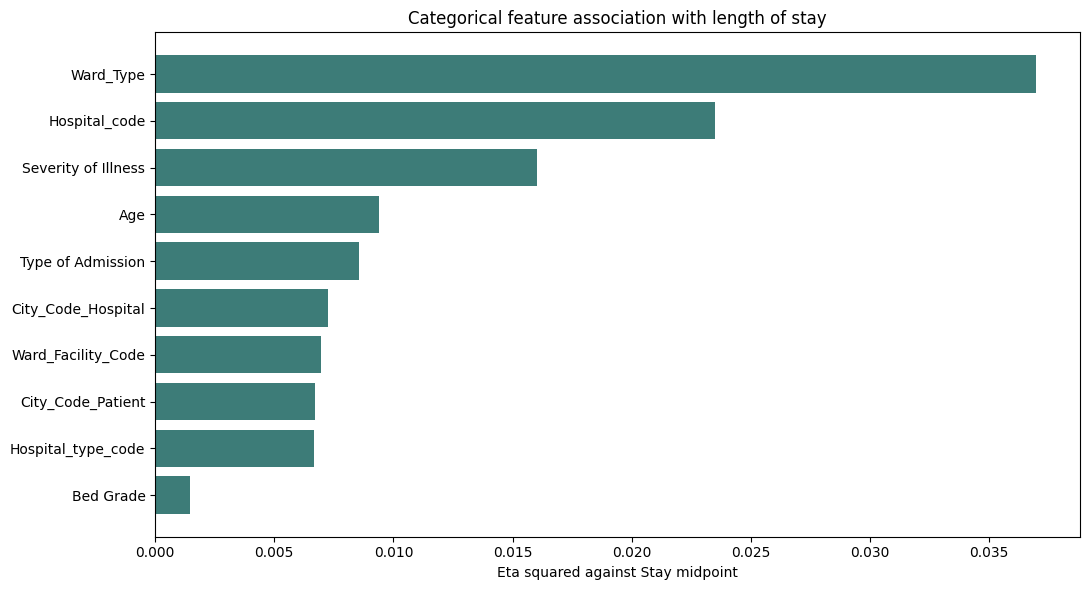

In [60]:
def show_categorical_association_plot(rows: list[dict[str, str]], columns: list[str], limit: int = 10) -> None:
    """Shows a bar chart of the strongest categorical associations with Stay. This helps to determine which categorical variables may be useful predictors."""
    plt = require_matplotlib()
    if plt is None:
        return

    associations = get_categorical_associations(rows, columns)[:limit]
    if not associations:
        print("No categorical associations are available to plot.")
        return

    labels = [row["feature"] for row in reversed(associations)]
    values = [row["eta_squared"] or 0 for row in reversed(associations)]

    plt.figure(figsize=(11, 6))
    plt.barh(labels, values, color="#3d7c78")
    plt.title("Categorical feature association with length of stay")
    plt.xlabel("Eta squared against Stay midpoint")
    plt.tight_layout()
    plt.show()

show_categorical_association_plot(rows, columns)

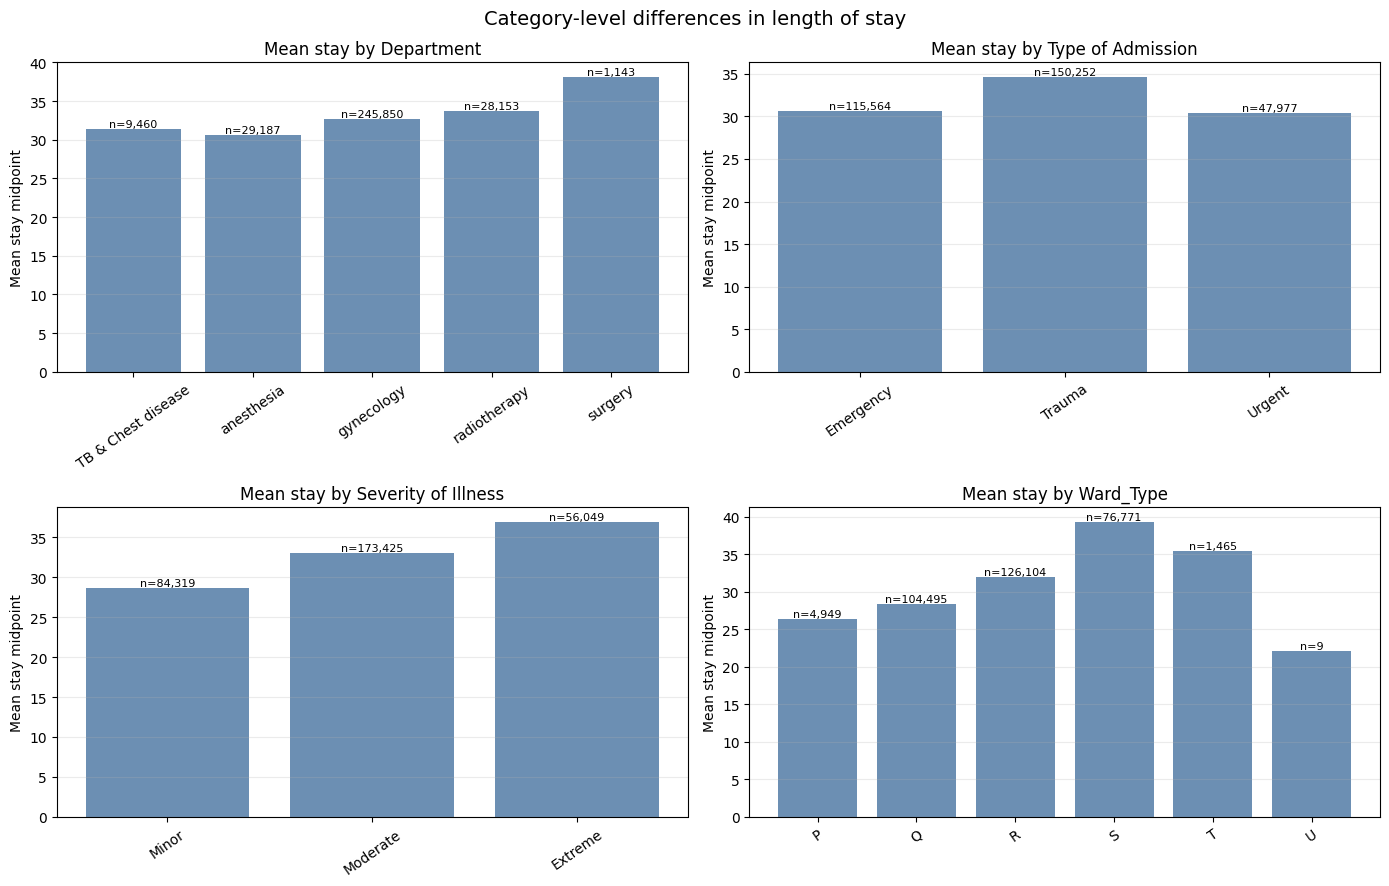

In [93]:
def show_mean_stay_bar_charts(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Shows bar charts of mean length of stay by important categorical features. (These plots are easy to explain in a presentation)"""
    plt = require_matplotlib()
    if plt is None:
        return

    available_features = [feature for feature in categorical_mean_stay_features if feature in columns]
    if not available_features:
        print("No categorical mean-stay features are available to plot.")
        return

    figure, axes = plt.subplots(2, 2, figsize=(14, 9))
    flat_axes = list(axes.flat)

    for axis, feature in zip(flat_axes, available_features):
        groups = get_grouped_stay_values(rows, feature)
        ordered_labels = order_values_for_plot(feature, list(groups.keys()))
        means = [statistics.mean(groups[label]) for label in ordered_labels]
        counts = [len(groups[label]) for label in ordered_labels]

        axis.bar(ordered_labels, means, color="#6c8fb3")
        axis.set_title(f"Mean stay by {feature}")
        axis.set_ylabel("Mean stay midpoint")
        axis.tick_params(axis="x", rotation=35)
        axis.grid(axis="y", alpha=0.25)

        for index, (mean_value, count) in enumerate(zip(means, counts)):
            axis.text(index, mean_value, f"n={count:,}", ha="center", va="bottom", fontsize=8)

    for axis in flat_axes[len(available_features):]:
        axis.axis("off")

    figure.suptitle("Category-level differences in length of stay", fontsize=14)
    plt.tight_layout()
    plt.show()

show_mean_stay_bar_charts(rows, columns)

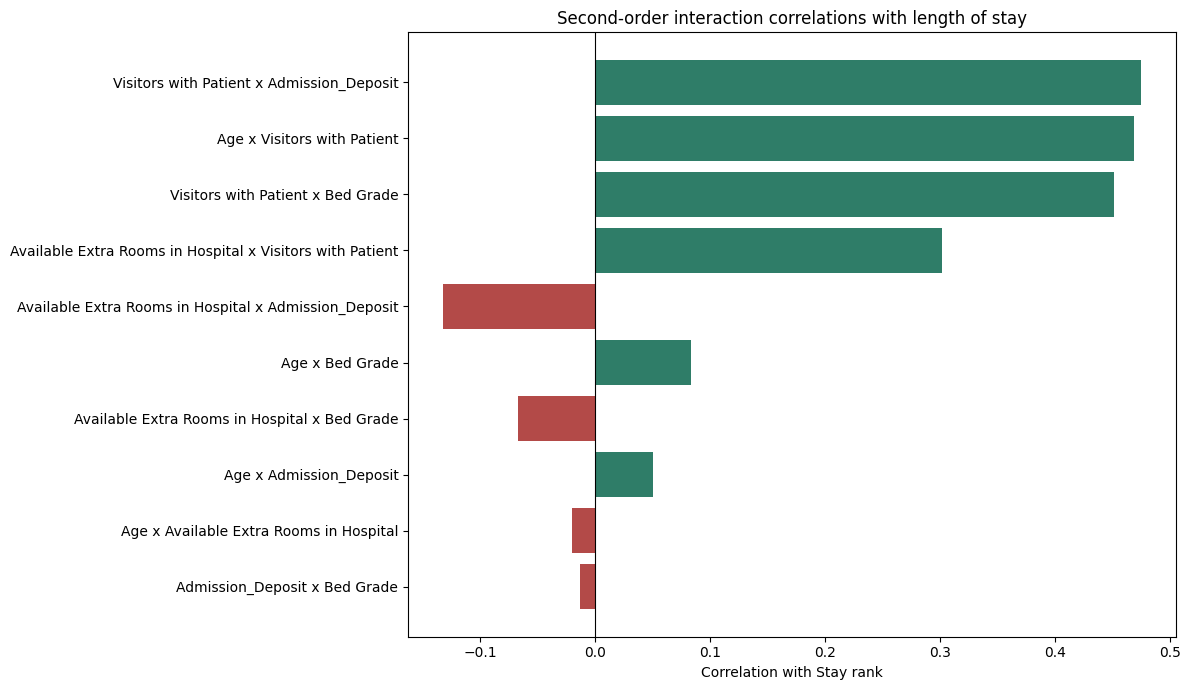

In [94]:
def show_interaction_correlation_plot(rows: list[dict[str, str]], columns: list[str], limit: int = 10) -> None:
    """Shows a bar chart of the strongest second-order interaction correlations with Stay."""
    plt = require_matplotlib()
    if plt is None:
        return

    interactions = get_second_order_interactions(rows, columns)[:limit]
    if not interactions:
        print("No interaction terms available to plot.")
        return

    labels = [row["interaction"] for row in reversed(interactions)]
    correlations = [row["correlation"] or 0 for row in reversed(interactions)]
    colors = ["#2f7d68" if value >= 0 else "#b34a48" for value in correlations]

    plt.figure(figsize=(12, 7))
    plt.barh(labels, correlations, color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Second-order interaction correlations with length of stay")
    plt.xlabel("Correlation with Stay rank")
    plt.tight_layout()
    plt.show()

show_interaction_correlation_plot(rows, columns)

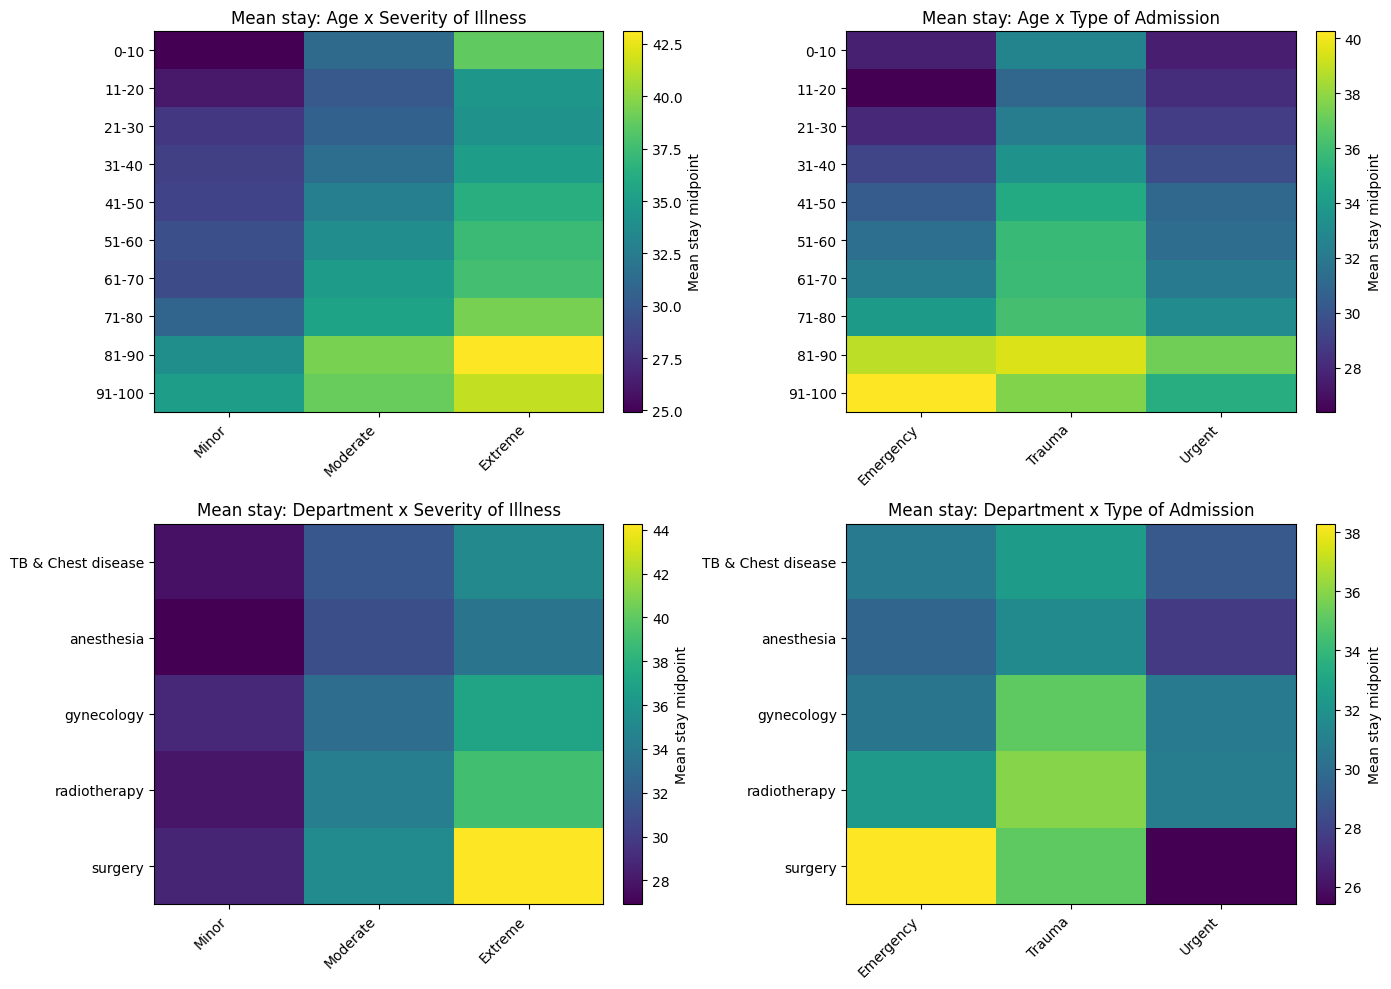

In [95]:
def show_mean_stay_heatmaps(rows: list[dict[str, str]], columns: list[str]) -> None:
    """Shows heatmaps of mean stay for selected pairs of categorical features. Help reveal interaction patterns between variables."""
    plt = require_matplotlib()
    if plt is None:
        return

    available_pairs = [(first, second) for first, second in heatmap_pairs if first in columns and second in columns]
    if not available_pairs:
        print("No configured heatmap pairs are available in the CSV columns.")
        return

    figure, axes = plt.subplots(2, 2, figsize=(14, 10))
    flat_axes = list(axes.flat)

    for axis, (first_column, second_column) in zip(flat_axes, available_pairs):
        first_values, second_values, matrix = build_mean_stay_matrix(rows, first_column, second_column)
        image = axis.imshow(matrix, aspect="auto", cmap="viridis")
        axis.set_title(f"Mean stay: {first_column} x {second_column}")
        axis.set_xticks(range(len(second_values)))
        axis.set_xticklabels(second_values, rotation=45, ha="right")
        axis.set_yticks(range(len(first_values)))
        axis.set_yticklabels(first_values)
        figure.colorbar(image, ax=axis, fraction=0.046, pad=0.04, label="Mean stay midpoint")

    for axis in flat_axes[len(available_pairs):]:
        axis.axis("off")

    plt.tight_layout()
    plt.show()

show_mean_stay_heatmaps(rows, columns)

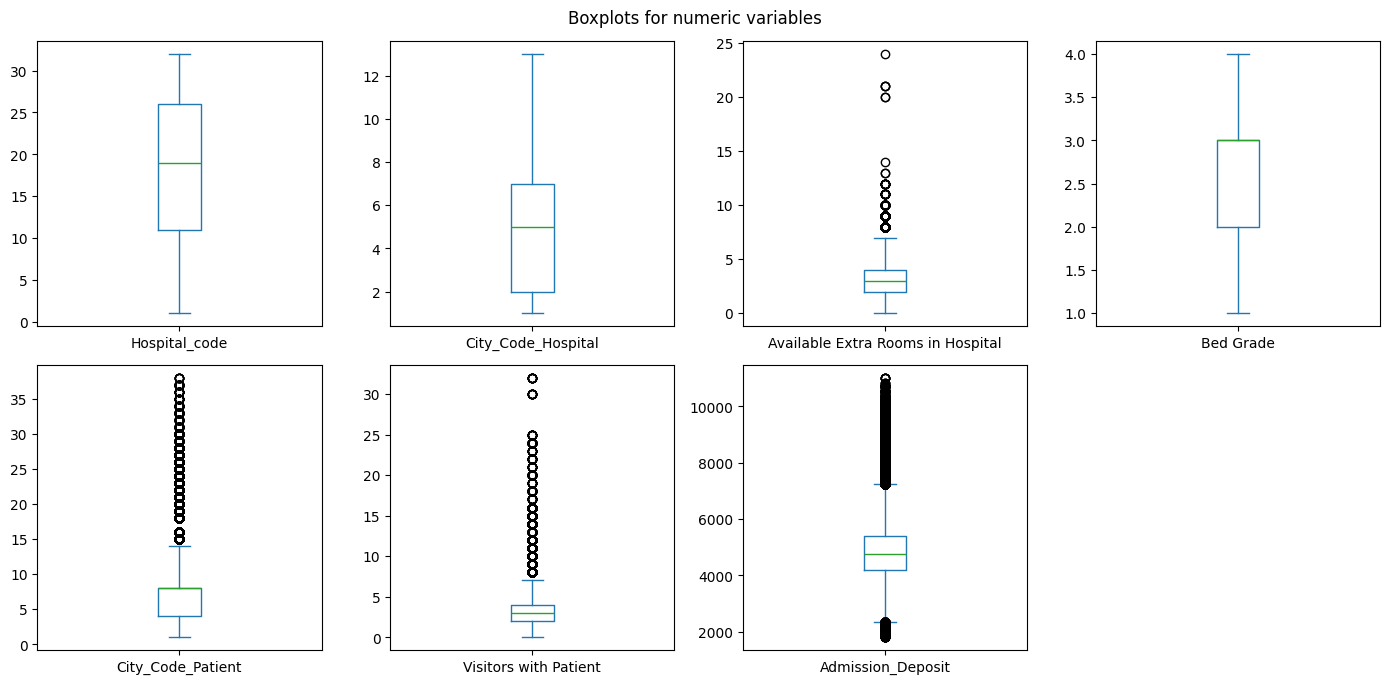

In [96]:
def show_boxplots_with_pandas(csv_path: Path) -> None:
    """Shows box-and-whisker plots for numeric columns. This is optional because the IQR table already reports numeric outliers!!!."""
    if pd is None:
        print("Boxplots need pandas and matplotlib. They are not installed in this Python environment.")
        return
    try:
        import matplotlib.pyplot as plt
    except ImportError:
        print("Boxplots need matplotlib. It is not installed in this Python environment.")
        return

    data = pd.read_csv(csv_path)
    plot_columns = [
        column
        for column in data.select_dtypes(include="number").columns
        if column not in identifier_columns
    ]
    if not plot_columns:
        print("No numeric columns available for boxplots.")
        return

    data[plot_columns].plot(kind="box", subplots=True, layout=(3, 4), figsize=(14, 10), sharey=False)
    plt.suptitle("Boxplots for numeric variables")
    plt.tight_layout()
    plt.show()

show_boxplots_with_pandas(csv_file)

In [97]:
def run_processing(
    csv_path: Path = csv_file,
    show_plots: bool = False,
) -> None:
    """Runs the complete preprocessing report: overview, missing values, duplicates, numeric summary, outliers, category validation, correlations, interactions, and grouped mean-stay analysis."""
    rows, columns = load_rows(csv_path)
    numeric_columns = infer_numeric_columns(rows, columns)

    print_basic_overview(rows, columns, numeric_columns)
    print_missing_values(rows, columns)
    print_duplicates(rows, columns)
    print_numeric_summary(rows, numeric_columns)
    print_outliers(rows, numeric_columns)
    print_unexpected_categories(rows, columns)
    print_correlations(rows, columns)
    print_categorical_associations(rows, columns)
    print_second_order_interactions(rows, columns)
    print_grouped_stay_means(rows, columns)

    if show_plots:
        show_boxplots_with_pandas(csv_path)

run_processing(csv_file)


----------------------------------------
Basic overview
----------------------------------------
Rows: 313,793
Columns: 18

Column types inferred from CSV text:
case_id: numeric
Hospital_code: numeric
Hospital_type_code: text/category
City_Code_Hospital: numeric
Hospital_region_code: text/category
Available Extra Rooms in Hospital: numeric
Department: text/category
Ward_Type: text/category
Ward_Facility_Code: text/category
Bed Grade: numeric
patientid: numeric
City_Code_Patient: numeric
Type of Admission: text/category
Severity of Illness: text/category
Visitors with Patient: numeric
Age: text/category
Admission_Deposit: numeric
Stay: text/category

----------------------------------------
Missing values
----------------------------------------
Rows with at least one missing value: 0 (0.00%)
No missing values found.

----------------------------------------
Duplicates
----------------------------------------
Fully duplicated rows: 0
case_id: 313,793 unique values, 0 repeated rows
pati